<html>
<body>
<h1 style="text-align:center; font-family: 'Arial', sans-serif; font-weight:bold; color:blue; background-color:white
 ;padding:20px">
  FIXY Data Analysis And Models
</h1>

</body>
</html>

# 📌 Project Summary

This project Analysis and Predict Rating for a home-services platform.  
It simulates interactions between **technicians** and **customers**, including service types, job conditions, ratings, and final satisfaction scores.  
The dataset is designed for **data analysis**, **machine learning experiments**, and **dashboard development**.

---

# 📊 Column Descriptions

## 🔧 Technician & Customer Info

| Column | Description |
|--------|-------------|
| `technician_id` | Unique ID for each technician. |
| `customer_id` | Unique ID for each customer. |
| `service_type` | Type of service requested (plumbing, electrical, AC repair, etc.). |


## 🕒 Timing & Context

| Column | Description |
|--------|-------------|
| `day_of_week` | The day the job took place (Mon–Sun). |
| `time_of_day` | When the job happened (morning, afternoon, evening, night). |
| `weather_condition` | Weather during the job (sunny, cloudy, rainy, stormy, hot). |


## ⏱ Operational Metrics

| Column | Description |
|--------|-------------|
| `job_duration` | Total time the technician spent working (minutes). |
| `response_time` | Time taken for the technician to arrive after the request. |


## ⭐ Technician Ratings (Customer → Worker)

| Column | Description |
|--------|-------------|
| `punctuality_rating` | Technician punctuality. |
| `professionalism_rating` | Professional behavior and skill. |
| `communication_rating` | Technician communication clarity. |
| `handling_quality` | Quality of handling tools, materials, and safety. |
| `cost_satisfaction` | Customer satisfaction with pricing and value. |


## ⭐ Customer Ratings (Worker → Customer)

| Column | Description |
|--------|-------------|
| `customer_punctuality` | Customer punctuality. |
| `customer_behavior` | Customer respect, attitude, and cooperation. |
| `clarity_of_issue` | How clearly the customer described the issue. |
| `safety_and_environment` | Cleanliness and safety level at customer’s place. |


## 🎯 Final Ratings

| Column | Description |
|--------|-------------|
| `cust_satisfaction` | Final score customer gives to the worker. |
| `worker_satisfaction` | Final score worker gives to the customer. |
| `final_rating` | Balanced final score (fair to both sides, weighted & corrected). |





<hr style="border: 2px solid #1b3fc3ff; width: 80%;">
<h1 style="text-align:center; font-family: 'Arial', sans-serif; color : white;">
1-Imports & Reading Data
</h1>
<hr style="border: 2px solid #1b3fc3ff; width: 80%;">

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px
%matplotlib inline

from sklearn.preprocessing import StandardScaler , RobustScaler ,LabelEncoder
from sklearn.model_selection import train_test_split ,GridSearchCV 
from sklearn.preprocessing import OrdinalEncoder ,OneHotEncoder 


from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier , AdaBoostClassifier ,ExtraTreesClassifier 
from sklearn.svm import SVC
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from imblearn.under_sampling import RandomUnderSampler
from sklearn.ensemble import VotingClassifier

from sklearn.model_selection import KFold , StratifiedKFold
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, RocCurveDisplay,
    precision_recall_curve, average_precision_score
)

import warnings
warnings.filterwarnings('ignore')

from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)




In [20]:
df = pd.read_csv(r'/kaggle/input/rating-predicition/service_feedback_dataset_Last.csv')
df.head(8)

,technician_id,customer_id,service_type,day_of_week,time_of_day,weather_condition,job_duration_minutes,response_time_minutes,punctuality_rating,professionalism_rating,communication_rating,handling_quality,cost_satisfaction,customer_satisfaction,customer_behavior,clarity_of_issue,safety_and_environment,customer_punctuality,worker_satisfaction,final_rating
0,3649,75250,ac_repair,Thursday,morning,sunny,82.743051,25.509583,3.0,4.0,3.0,5.0,4.0,4.0,5.0,5.0,5.0,3.0,4.0,5.0
1,820,350,plumbing,Sunday,afternoon,cloudy,69.606202,14.229784,3.0,4.0,3.0,2.0,4.0,3.0,5.0,4.0,4.0,4.0,4.0,4.0
2,9013,65125,appliance_repair,Monday,afternoon,cloudy,44.779811,21.356473,4.0,4.0,4.0,4.0,4.0,4.0,4.0,2.0,3.0,5.0,4.0,5.0
3,8025,87161,cleaning,Thursday,afternoon,cloudy,56.019392,26.201402,3.0,3.0,3.0,NaN,4.0,3.0,4.0,4.0,3.0,5.0,4.0,3.0
4,7315,53466,cleaning,Thursday,evening,cloudy,60.110322,18.383508,3.0,3.0,3.0,3.0,4.0,3.0,3.0,4.0,3.0,3.0,3.0,2.0
5,4573,26542,ac_repair,Monday,morning,rainy,105.291378,15.857763,4.0,5.0,4.0,4.0,3.0,4.0,3.0,3.0,4.0,2.0,3.0,5.0
6,3359,49032,electrical,Saturday,afternoon,sunny,66.553323,29.684291,3.0,4.0,NaN,4.0,5.0,4.0,5.0,3.0,2.0,3.0,3.0,4.0
7,17871,72227,furniture_moving,Sunday,evening,sunny,153.748949,6.553540,4.0,4.0,4.0,4.0,4.0,4.0,5.0,4.0,5.0,4.0,4.0,5.0




<hr style="border: 2px solid #1b3fc3ff; width: 80%;">
<h1 style="text-align:center; font-family: 'Arial', sans-serif; color : white;">
2 - Exploratory Data Analysis
</h1>
<hr style="border: 2px solid #1b3fc3ff; width: 80%;">

In [21]:
df['final_rating'].value_counts()

final_rating
5.0    104705
4.0     74814
3.0     59871
2.0     35917
1.0     23934
Name: count, dtype: int64

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 20 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   technician_id           300000 non-null  int64  
 1   customer_id             300000 non-null  int64  
 2   service_type            300000 non-null  object 
 3   day_of_week             300000 non-null  object 
 4   time_of_day             300000 non-null  object 
 5   weather_condition       300000 non-null  object 
 6   job_duration_minutes    296377 non-null  float64
 7   response_time_minutes   295716 non-null  float64
 8   punctuality_rating      298446 non-null  float64
 9   professionalism_rating  295492 non-null  float64
 10  communication_rating    296436 non-null  float64
 11  handling_quality        293904 non-null  float64
 12  cost_satisfaction       290982 non-null  float64
 13  customer_satisfaction   292429 non-null  float64
 14  customer_behavior   

In [23]:
df.describe()

,technician_id,customer_id,job_duration_minutes,response_time_minutes,punctuality_rating,professionalism_rating,communication_rating,handling_quality,cost_satisfaction,customer_satisfaction,customer_behavior,clarity_of_issue,safety_and_environment,customer_punctuality,worker_satisfaction,final_rating
count,300000.000000,300000.000000,296377.000000,295716.000000,298446.000000,295492.000000,296436.000000,293904.000000,290982.000000,292429.000000,298547.000000,297646.000000,294009.000000,297285.000000,299713.000000,299241.000000
mean,9989.750663,59975.895927,95.072002,26.238909,3.390282,3.516525,3.297100,3.420117,3.667663,3.466123,3.515761,3.544398,3.590166,3.582034,3.680391,3.669825
std,5776.735047,34644.225832,55.866463,24.485944,0.697047,0.777892,0.678932,0.789969,0.649742,0.549733,0.837613,0.705957,0.664361,0.868007,0.486606,1.280983
min,1.000000,1.000000,10.001111,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000
25%,4972.000000,29937.750000,56.670289,10.337569,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
50%,9978.000000,59941.000000,84.449297,18.804704,3.000000,4.000000,3.000000,3.000000,4.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000
75%,15003.000000,90004.250000,122.161050,33.674466,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000
max,20000.000000,120000.000000,903.963537,600.417873,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


### Unique Values

In [24]:
for col in df.columns:
    print(col)
    print(df[col].unique())
    print('-------------------')

technician_id
[ 3649   820  9013 ... 16834 15662  2881]
-------------------
customer_id
[ 75250    350  65125 ...  91559  91558 114911]
-------------------
service_type
['ac_repair' 'plumbing' 'appliance_repair' 'cleaning' 'electrical'
 'furniture_moving' 'delivery' 'satellite_installation' 'roof_leak_repair'
 'carpentry' 'locksmith' 'furniture_assembly' 'pest_control' 'it_support'
 'painting']
-------------------
day_of_week
['Thursday' 'Sunday' 'Monday' 'Saturday' 'Tuesday' 'Friday' 'Wednesday']
-------------------
time_of_day
['morning' 'afternoon' 'evening' 'night']
-------------------
weather_condition
['sunny' 'cloudy' 'rainy' 'stormy' 'hot']
-------------------
job_duration_minutes
[82.7430509  69.60620203 44.77981118 ... 71.42641164 98.08240813
 76.64393245]
-------------------
response_time_minutes
[25.50958275 14.22978372 21.35647259 ... 48.39327743 13.18548325
 30.36169996]
-------------------
punctuality_rating
[ 3.  4.  2.  5.  1. nan]
-------------------
professionalism_r

### Missing Data

In [25]:
df.isna().sum().sort_values(ascending=False)

cost_satisfaction         9018
customer_satisfaction     7571
handling_quality          6096
safety_and_environment    5991
professionalism_rating    4508
response_time_minutes     4284
job_duration_minutes      3623
communication_rating      3564
customer_punctuality      2715
clarity_of_issue          2354
punctuality_rating        1554
customer_behavior         1453
final_rating               759
worker_satisfaction        287
customer_id                  0
technician_id                0
day_of_week                  0
service_type                 0
weather_condition            0
time_of_day                  0
dtype: int64

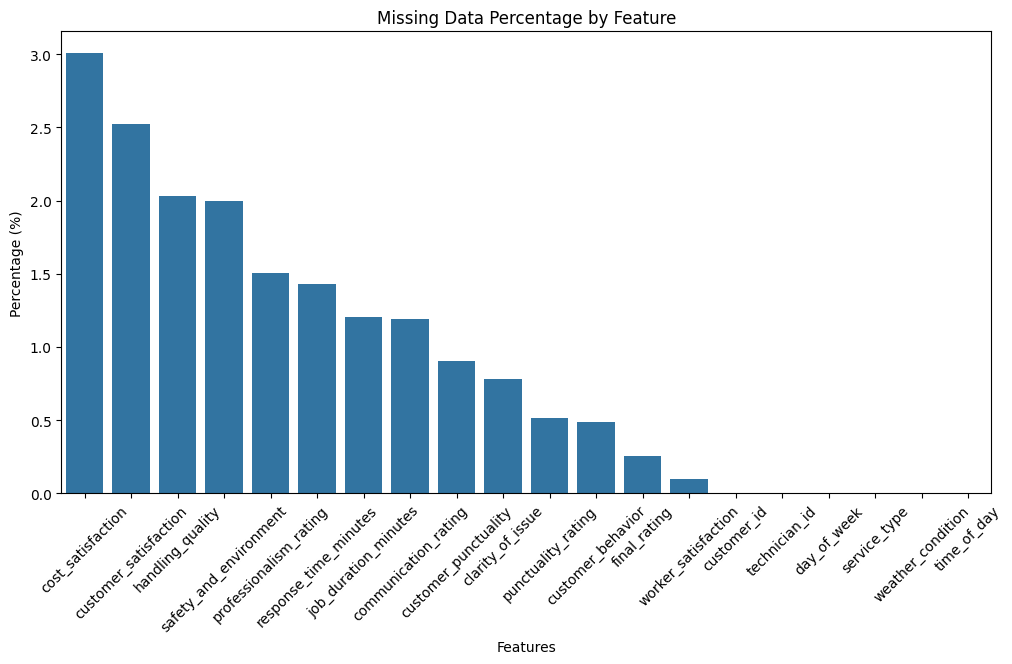

In [26]:
missing_percentage = df.isna().sum() / len(df) * 100
missing_percentage = missing_percentage.to_frame(name='Missing Percentage').sort_values(
    by='Missing Percentage', ascending=False
)

plt.figure(figsize=(12, 6))  
sns.barplot(x=missing_percentage.index, y='Missing Percentage', data=missing_percentage)
plt.xticks(rotation=45)
plt.title("Missing Data Percentage by Feature")
plt.xlabel("Features")
plt.ylabel("Percentage (%)")
plt.show()


In [27]:
df.dropna(inplace=True)
df.shape

(250418, 20)

### Duplicated Values

In [28]:
df.duplicated().sum()

np.int64(0)

In [29]:
df[df['technician_id']== 2000]

,technician_id,customer_id,service_type,day_of_week,time_of_day,weather_condition,job_duration_minutes,response_time_minutes,punctuality_rating,professionalism_rating,communication_rating,handling_quality,cost_satisfaction,customer_satisfaction,customer_behavior,clarity_of_issue,safety_and_environment,customer_punctuality,worker_satisfaction,final_rating
31221,2000,75949,electrical,Friday,afternoon,cloudy,82.884160,15.741240,4.0,3.0,4.0,3.0,3.0,3.0,4.0,3.0,4.0,3.0,4.0,3.0
35915,2000,41834,electrical,Friday,afternoon,sunny,71.355427,21.509643,4.0,3.0,3.0,4.0,3.0,3.0,2.0,2.0,4.0,3.0,3.0,2.0
94357,2000,12137,electrical,Thursday,morning,cloudy,134.045840,7.239322,3.0,3.0,4.0,4.0,3.0,3.0,3.0,4.0,4.0,3.0,4.0,3.0
141050,2000,97737,electrical,Tuesday,evening,sunny,96.054282,12.292350,4.0,3.0,3.0,4.0,3.0,3.0,3.0,4.0,4.0,2.0,3.0,2.0
142345,2000,93956,electrical,Thursday,evening,sunny,93.072007,11.098441,4.0,3.0,3.0,4.0,4.0,4.0,3.0,4.0,4.0,5.0,4.0,5.0
155323,2000,71770,electrical,Sunday,evening,cloudy,85.743818,31.630980,4.0,4.0,3.0,4.0,3.0,4.0,3.0,3.0,3.0,3.0,3.0,4.0
205550,2000,33914,electrical,Wednesday,morning,stormy,84.345815,17.880489,4.0,3.0,3.0,3.0,4.0,3.0,4.0,4.0,5.0,5.0,4.0,3.0
210828,2000,77830,electrical,Thursday,morning,sunny,78.752843,29.667083,4.0,3.0,3.0,4.0,4.0,4.0,4.0,3.0,3.0,3.0,3.0,4.0
216115,2000,68310,electrical,Tuesday,evening,cloudy,91.265943,83.147853,4.0,3.0,3.0,2.0,3.0,3.0,5.0,5.0,3.0,4.0,5.0,3.0
232831,2000,35538,electrical,Tuesday,evening,sunny,91.434597,45.942311,4.0,3.0,4.0,4.0,4.0,4.0,4.0,3.0,3.0,5.0,4.0,5.0


### This indicates that each technician has only one job

In [30]:
df.drop(columns=['technician_id','customer_id'] , inplace=True)

In [31]:
num_col = df.select_dtypes(include=['int64', 'float64']).columns
cat_col = df.select_dtypes(include=['object']).columns

print(num_col)
print(cat_col)

Index(['job_duration_minutes', 'response_time_minutes', 'punctuality_rating',
       'professionalism_rating', 'communication_rating', 'handling_quality',
       'cost_satisfaction', 'customer_satisfaction', 'customer_behavior',
       'clarity_of_issue', 'safety_and_environment', 'customer_punctuality',
       'worker_satisfaction', 'final_rating'],
      dtype='object')
Index(['service_type', 'day_of_week', 'time_of_day', 'weather_condition'], dtype='object')


In [32]:
rating_columns = [ 'punctuality_rating', 'professionalism_rating', 'communication_rating', 'handling_quality',
                    'cost_satisfaction', 'customer_behavior', 'clarity_of_issue', 'safety_and_environment', 
                   'customer_satisfaction' ,'worker_satisfaction','customer_punctuality', 'final_rating']
 
timed_columns = ['job_duration_minutes', 'response_time_minutes']

### Outlier Detection

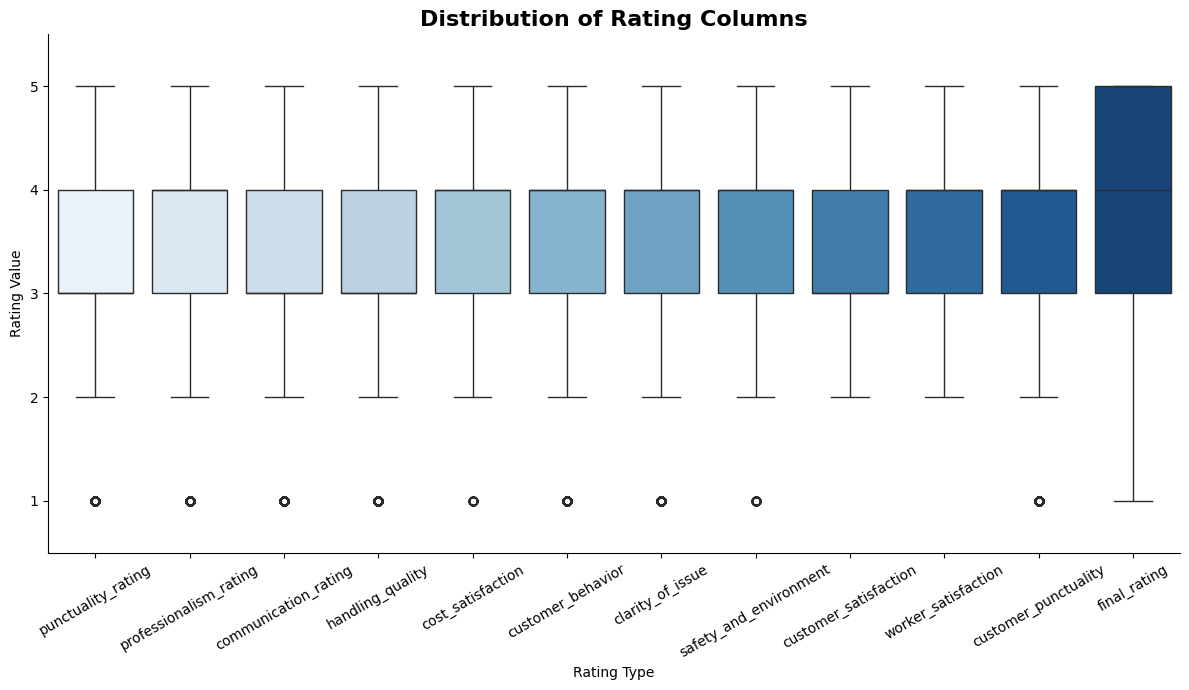

In [33]:
plt.figure(figsize=(12, 7))

sns.boxplot(
    data=df[rating_columns],
    palette="Blues"
)

plt.title("Distribution of Rating Columns", fontsize=16, fontweight="bold")
plt.xlabel("Rating Type")
plt.ylabel("Rating Value")

plt.xticks(rotation=30)
plt.ylim(0.5, 5.5)

sns.despine()
plt.tight_layout()
plt.show()


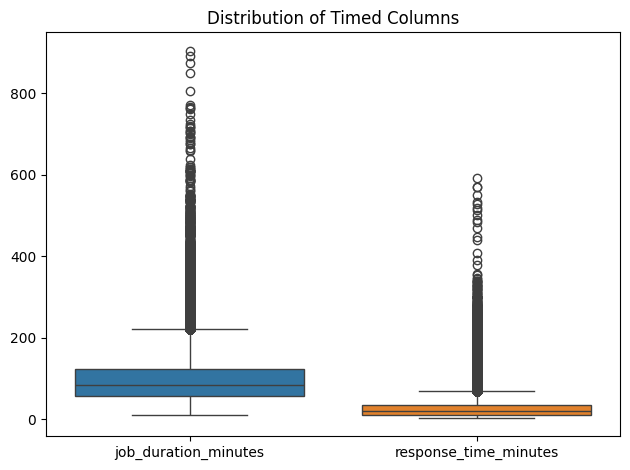

In [34]:
sns.boxplot(data=df[timed_columns])
plt.title("Distribution of Timed Columns")
plt.tight_layout()
plt.show()

In [35]:
def outlier_reomoval(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    filtered_df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return filtered_df

for col in timed_columns:
    df = outlier_reomoval(df, col)

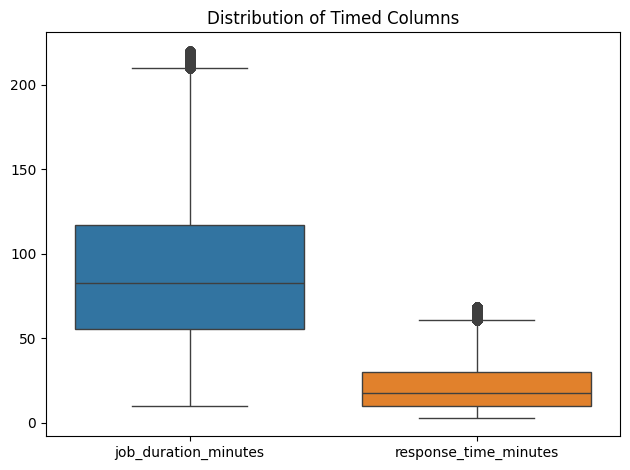

In [36]:
sns.boxplot(data=df[timed_columns])
plt.title("Distribution of Timed Columns")
plt.tight_layout()
plt.show()

### Univarate Analysis ###

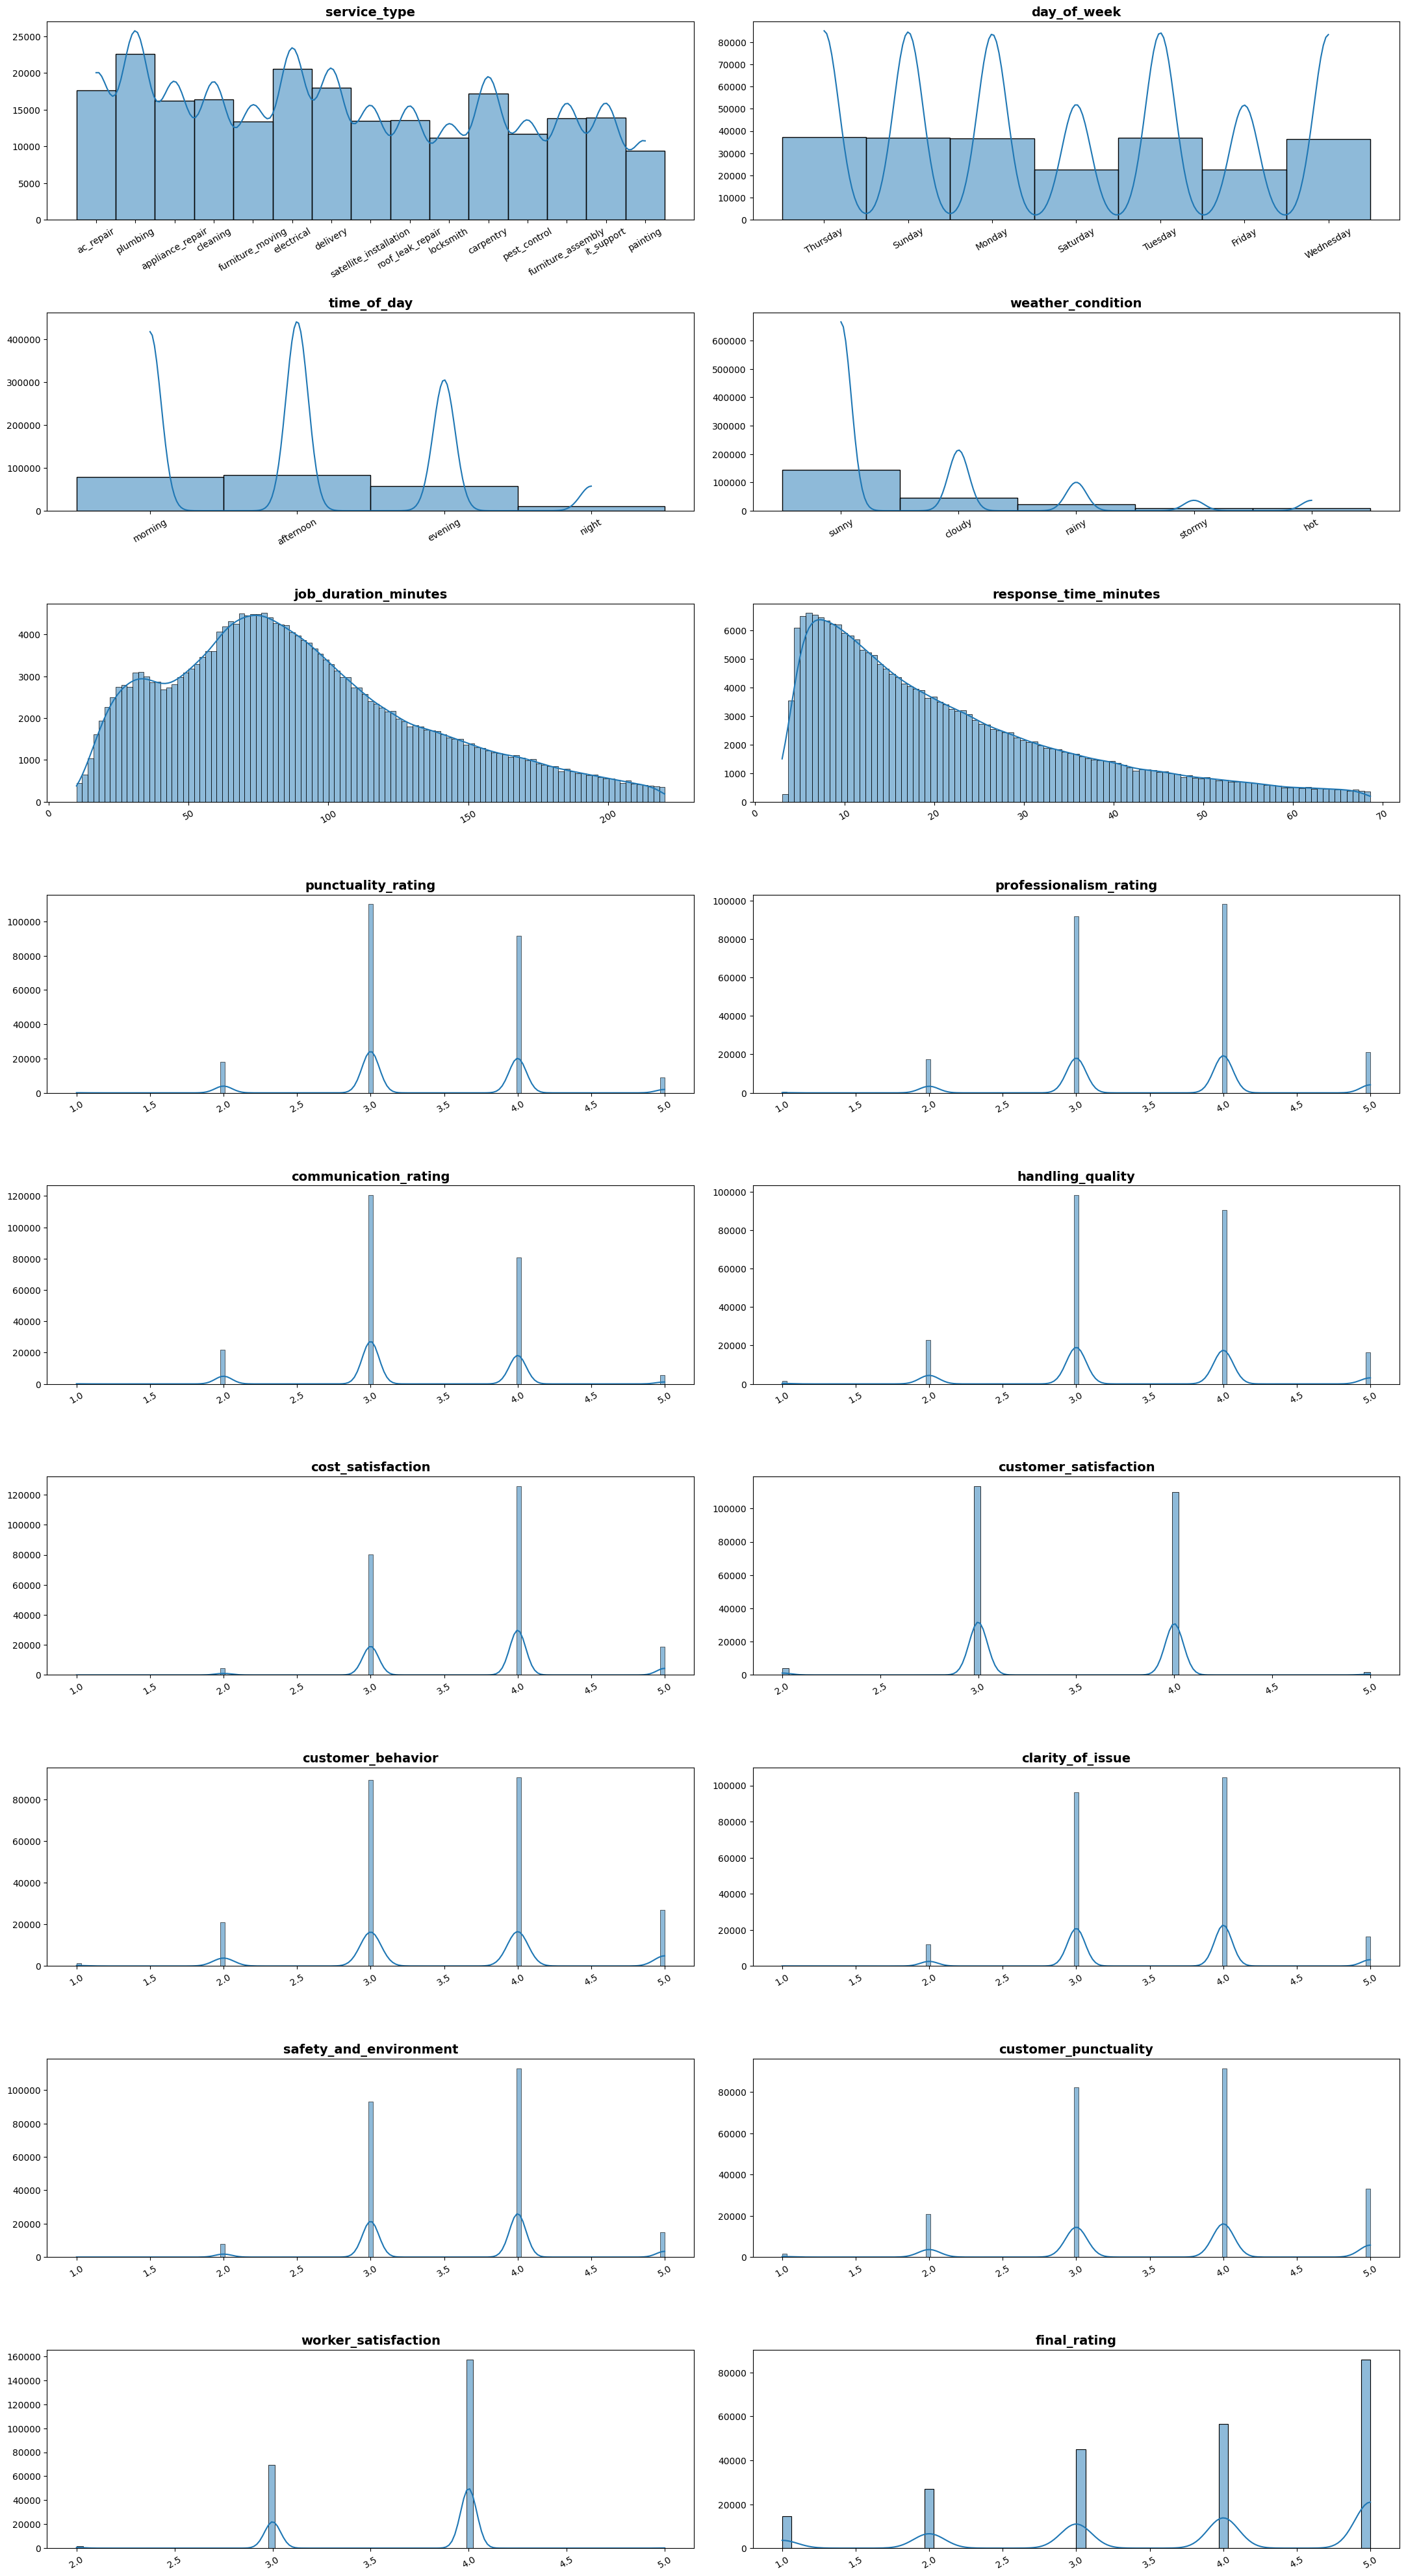

In [37]:
plt.figure(figsize=(22, 40))   
i=1
for  col in df.columns:
    plt.subplot(9, 2, i)

    sns.histplot(df[col], kde=True)
    
    plt.title(col, fontsize=14, fontweight='bold') 
    plt.xlabel("")
    plt.ylabel("")
    plt.xticks(rotation=30, fontsize=10)
    plt.yticks(fontsize=10)
    i+=1

    plt.grid(False)  
plt.tight_layout(pad=2.0) 
plt.show()


### Bi Virate Analysis

#### Timing Impact

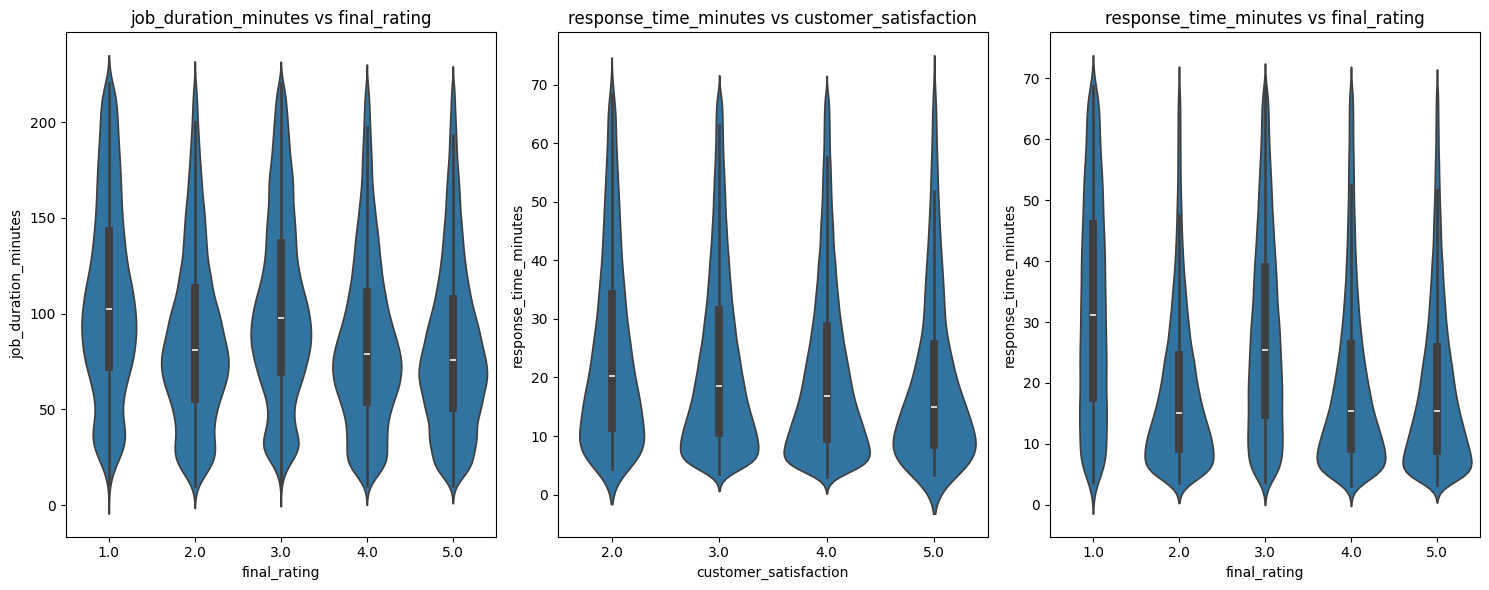

In [38]:
#job_duration_minutes × final_rating
plt.figure(figsize=(15, 6))
plt.subplot(1, 3, 1)
sns.violinplot(x='final_rating', y='job_duration_minutes', data=df)
plt.title('job_duration_minutes vs final_rating')
plt.xlabel('final_rating')
plt.ylabel('job_duration_minutes')

#response_time_minutes × customer_satisfaction
plt.subplot(1, 3, 2)
sns.violinplot(x='customer_satisfaction', y='response_time_minutes', data=df)
plt.title('response_time_minutes vs customer_satisfaction')
plt.xlabel('customer_satisfaction')
plt.ylabel('response_time_minutes')

#response_time_minutes × final_rating
plt.subplot(1, 3, 3)
sns.violinplot(x='final_rating', y='response_time_minutes', data=df)
plt.title('response_time_minutes vs final_rating')
plt.xlabel('final_rating')
plt.ylabel('response_time_minutes')

plt.tight_layout()
plt.show()

#### Quality Impact

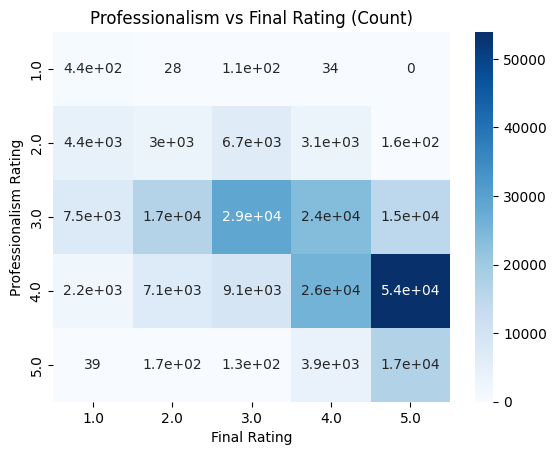

In [39]:
pivot = df.pivot_table(
    index='professionalism_rating',
    columns='final_rating',
    aggfunc='size',
    fill_value=0)


sns.heatmap(pivot, annot=True, cmap='Blues')
plt.title("Professionalism vs Final Rating (Count)")
plt.xlabel("Final Rating")
plt.ylabel("Professionalism Rating")
plt.show()


#### Cost and Satisfication

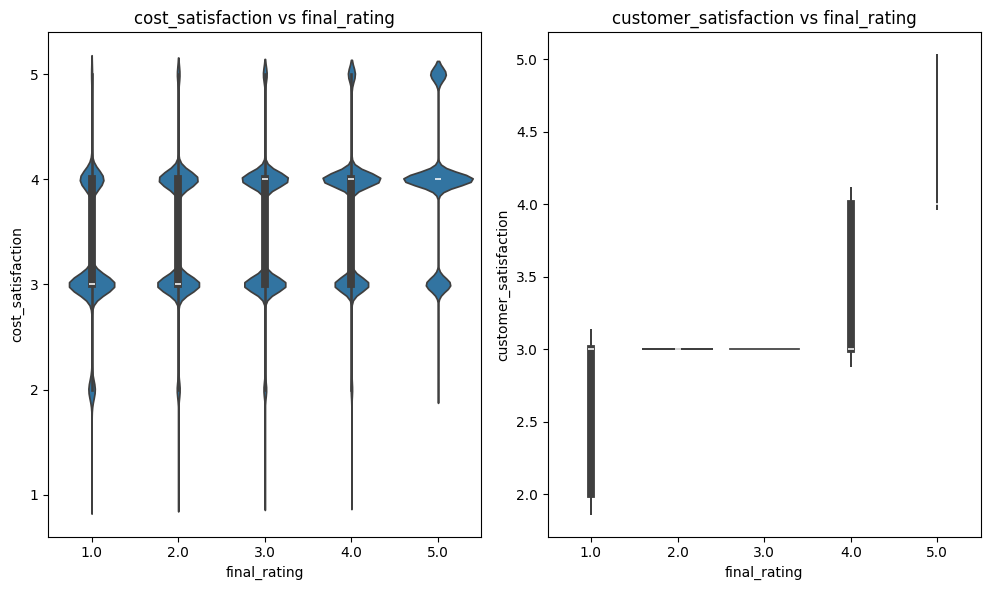

In [40]:
plt.figure(figsize=(15, 6))
plt.subplot(1, 3, 1)
sns.violinplot(x='final_rating', y='cost_satisfaction', data=df)
plt.title('cost_satisfaction vs final_rating')
plt.xlabel('final_rating')
plt.ylabel('cost_satisfaction')
# customer_satisfaction × final_rating
plt.subplot(1, 3, 2)
sns.violinplot(x='final_rating', y='customer_satisfaction', data=df)
plt.title('customer_satisfaction vs final_rating')
plt.xlabel('final_rating')
plt.ylabel('customer_satisfaction')

plt.tight_layout()
plt.show()


#### Service Type 

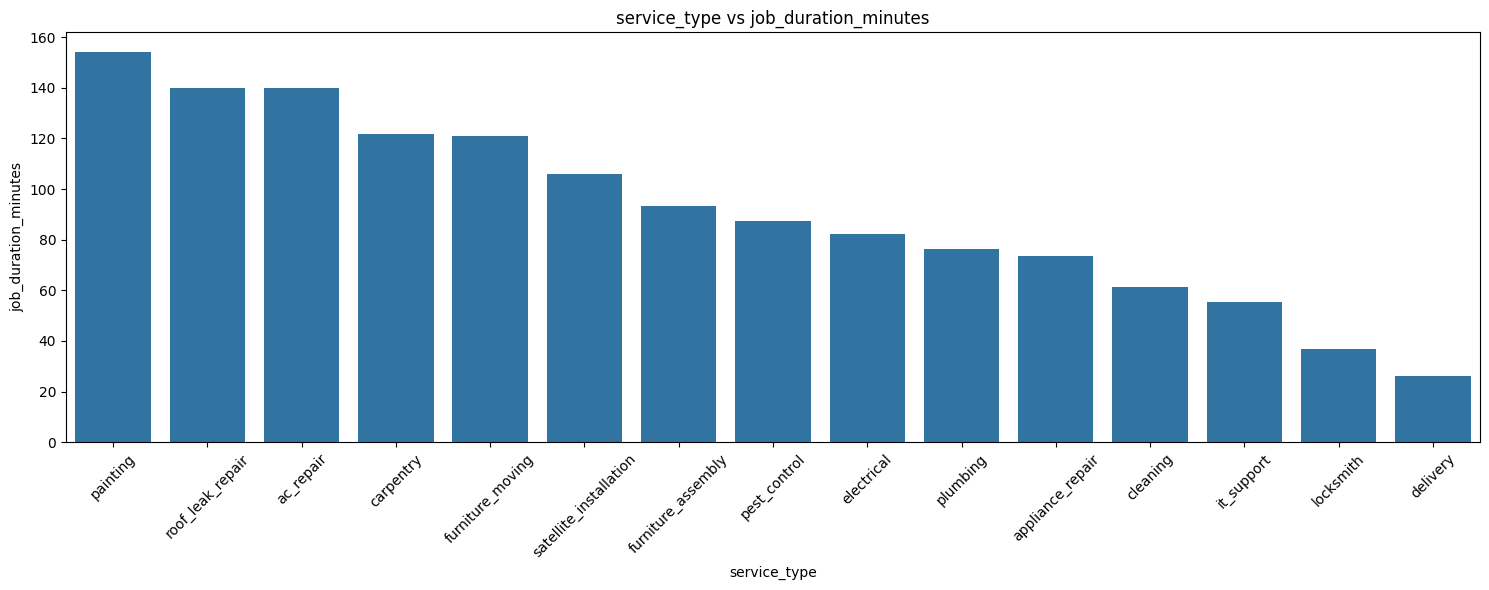

In [41]:
#service_type × job_duration_minutes
plt.figure(figsize=(15, 6))
jobs_Avg_Minutes =df.groupby('service_type')['job_duration_minutes'].mean().reset_index().sort_values(by='job_duration_minutes', ascending=False)
sns.barplot(x='service_type', y='job_duration_minutes', data=jobs_Avg_Minutes)
plt.title('service_type vs job_duration_minutes')
plt.xlabel('service_type')
plt.ylabel('job_duration_minutes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Influence of external factors

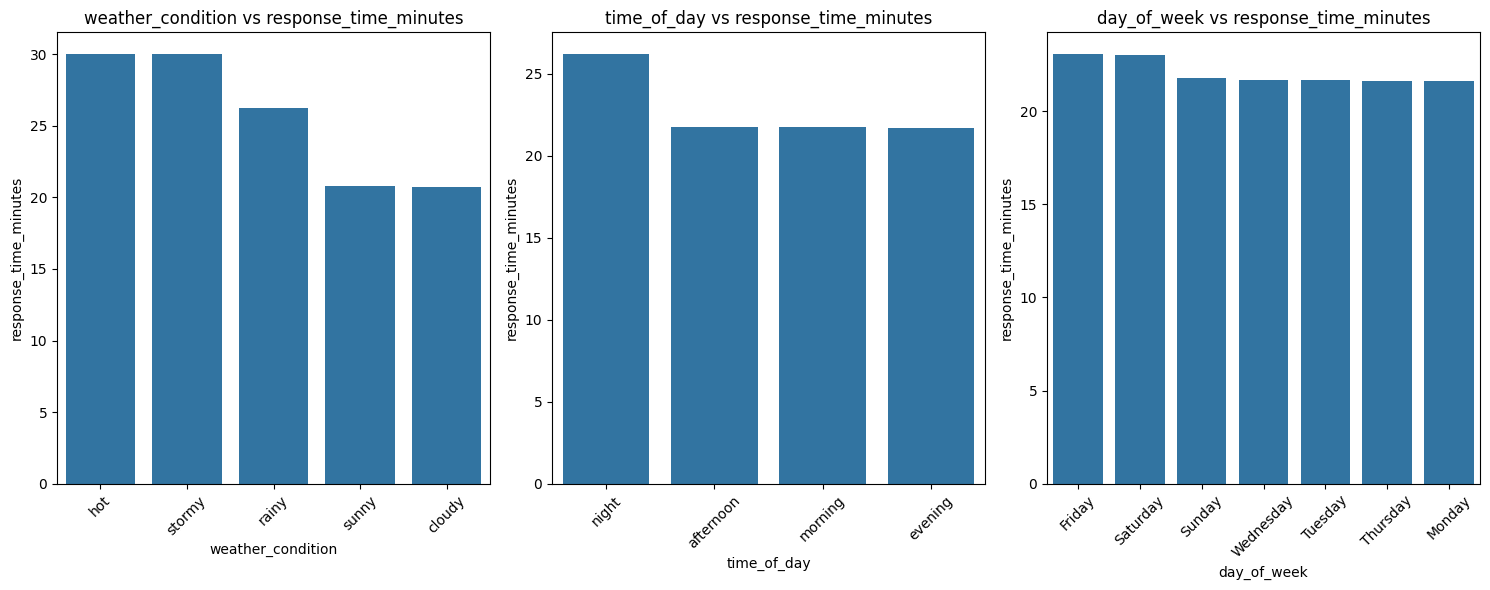

In [42]:
plt.figure(figsize=(15, 6))
external_Features = ['weather_condition', 'time_of_day', 'day_of_week']
i =1 


for fature in external_Features:
    plt.subplot(1 ,3, i)
    Avg_minutes =df.groupby(fature)['response_time_minutes'].mean().reset_index().sort_values(by='response_time_minutes', ascending=False)
    sns.barplot(x=fature, y='response_time_minutes', data=Avg_minutes)
    plt.title(fature + ' vs response_time_minutes')
    plt.xlabel(fature)
    plt.ylabel('response_time_minutes')
    plt.xticks(rotation=45)
    plt.tight_layout()
    i+=1
plt.show()


#### Impact On Final Rating

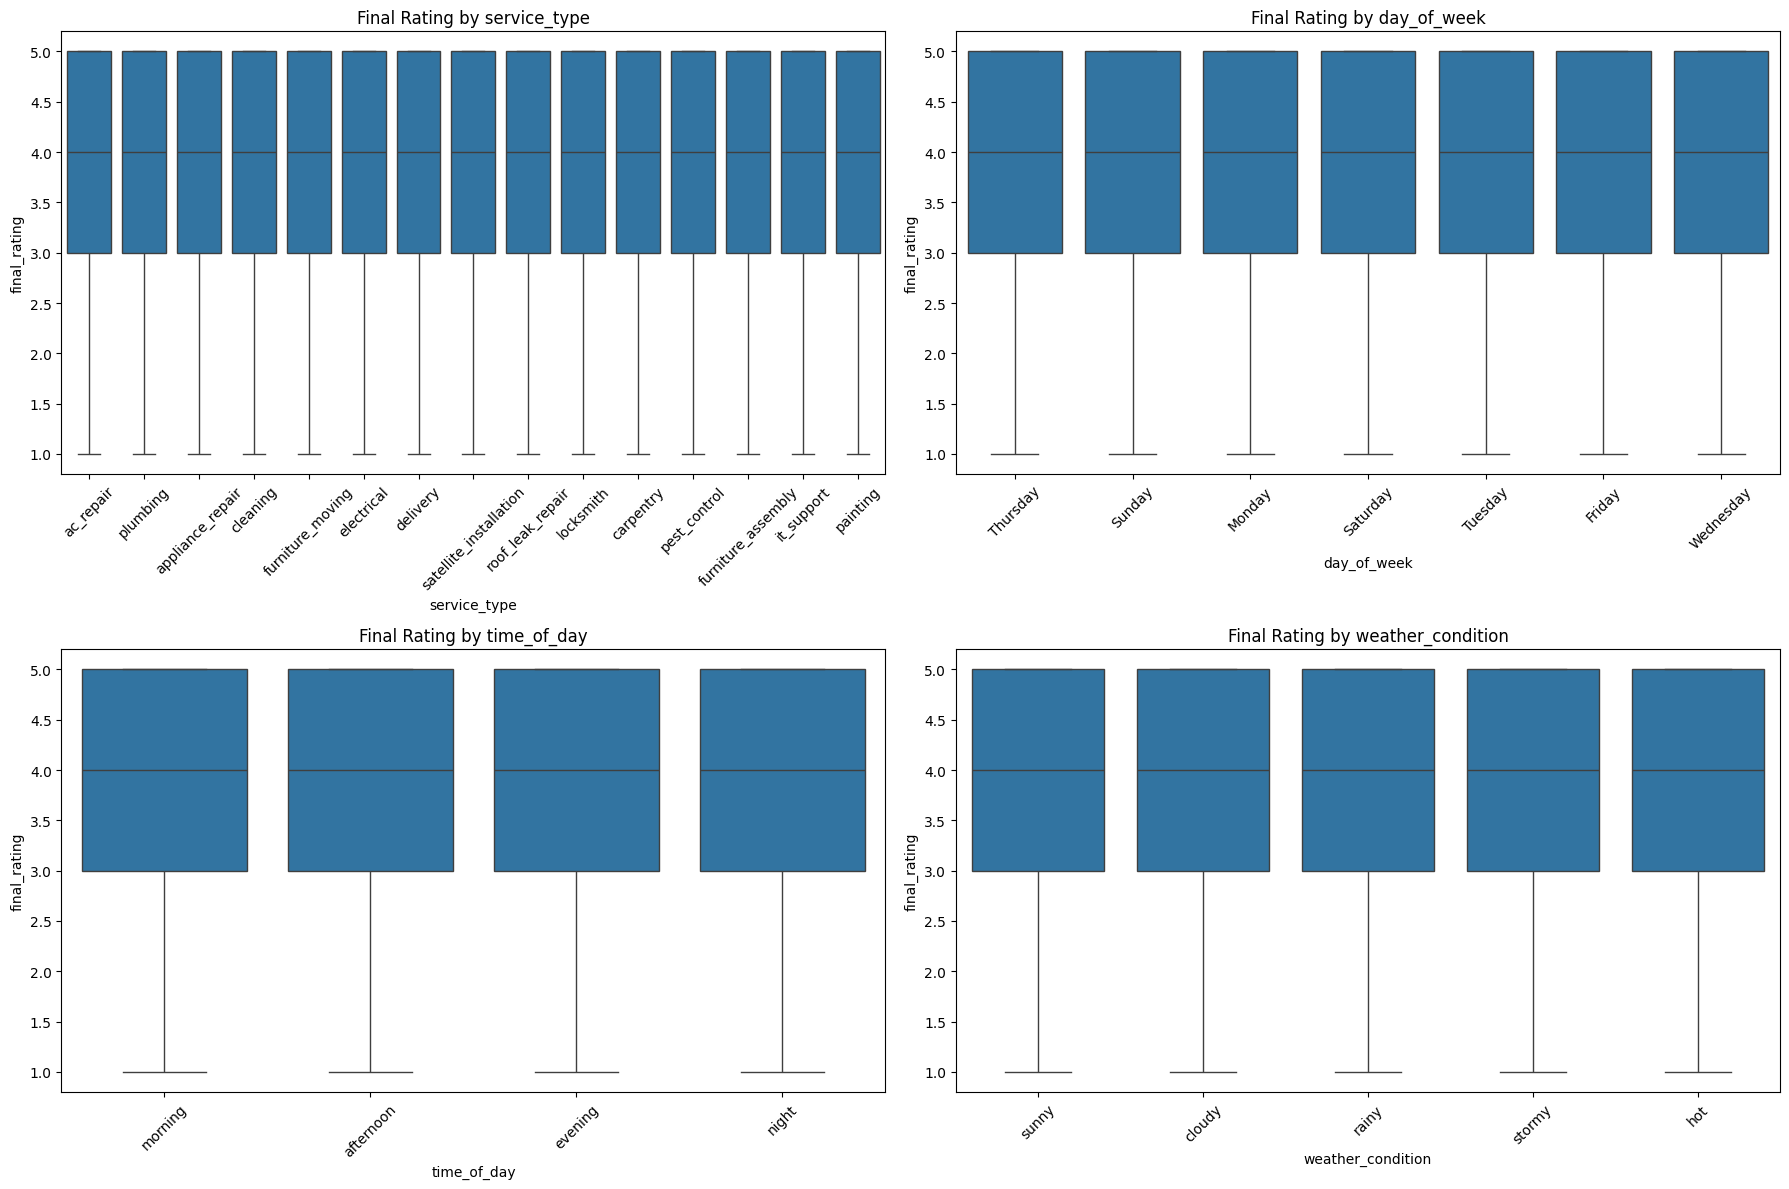

In [43]:
plt.figure(figsize=(18, 12))
for i, col in enumerate(cat_col, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=df, x=col, y='final_rating')
    plt.xticks(rotation=45)
    plt.title(f'Final Rating by {col}')
plt.tight_layout()
plt.show()

### Multi Virate Analysis

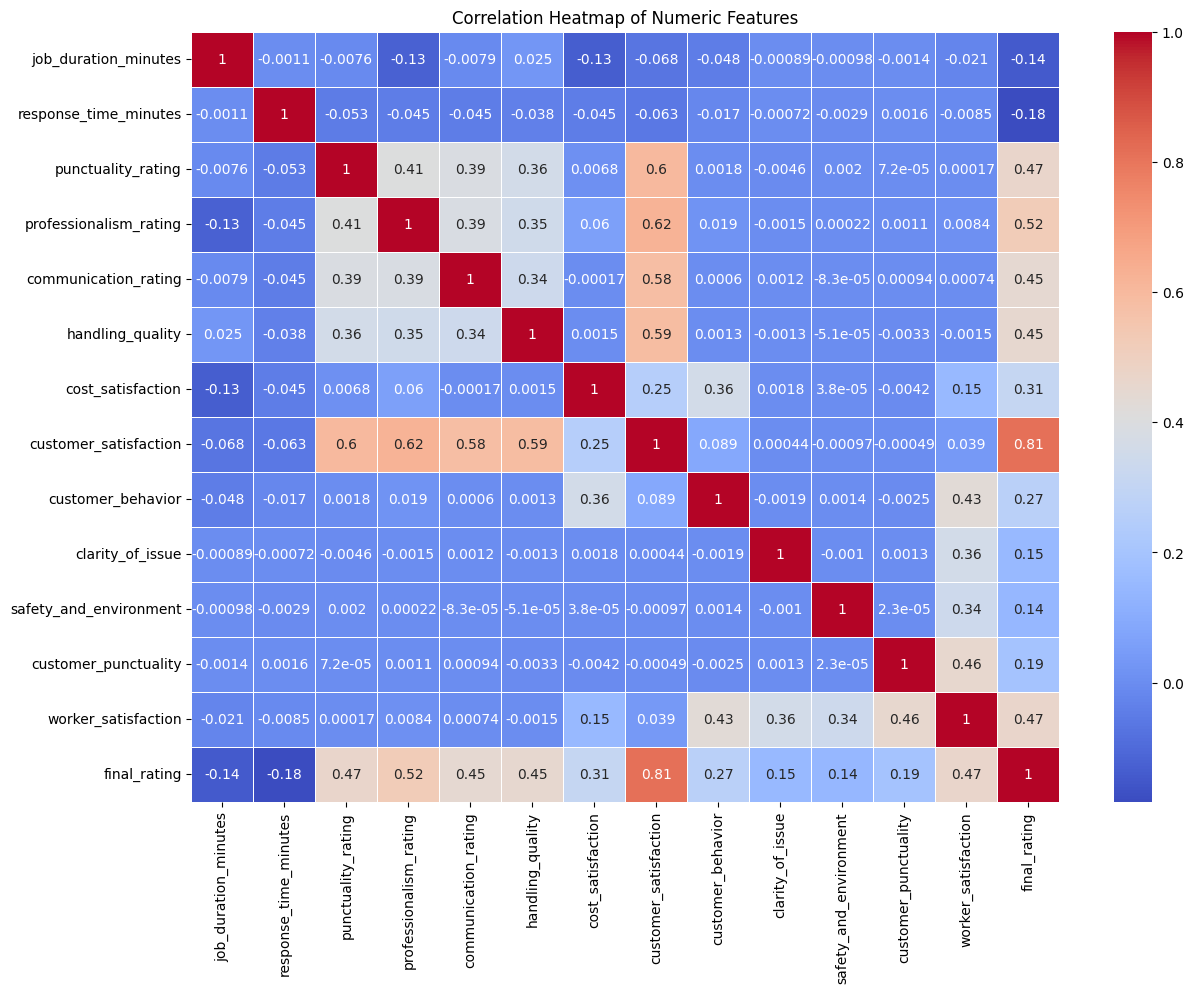

In [44]:
plt.figure(figsize=(14, 10))
corr = df[num_col].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

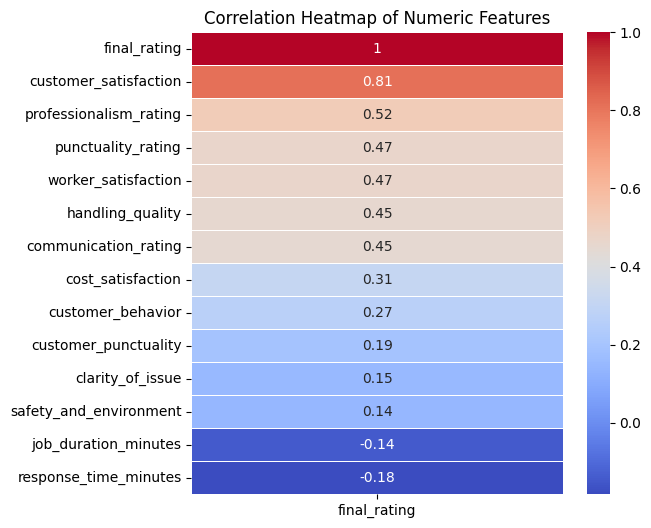

In [45]:
plt.figure(figsize=(6, 6))
corr = df[num_col].corr()
corr_with_rating = corr['final_rating'].sort_values(ascending=False).to_frame()

sns.heatmap(corr_with_rating, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()



<hr style="border: 2px solid #1b3fc3ff; width: 80%;">
<h1 style="text-align:center; font-family: 'Arial', sans-serif; color : white;">
3 - Preprocessiong</h1>
<hr style="border: 2px solid #1b3fc3ff; width: 80%;">

## I will drop these two features to avoid data leakage 

In [46]:
df.drop(columns=['customer_satisfaction' ,'worker_satisfaction'] , inplace=True)

#### **Data Encoding**

In [47]:
df_encoded = pd.get_dummies(df, columns=['service_type', 'day_of_week', 'weather_condition' ,'time_of_day' ])


In [48]:
df_encoded.head()

,job_duration_minutes,response_time_minutes,punctuality_rating,professionalism_rating,communication_rating,handling_quality,cost_satisfaction,customer_behavior,clarity_of_issue,safety_and_environment,...,day_of_week_Wednesday,weather_condition_cloudy,weather_condition_hot,weather_condition_rainy,weather_condition_stormy,weather_condition_sunny,time_of_day_afternoon,time_of_day_evening,time_of_day_morning,time_of_day_night
0,82.743051,25.509583,3.0,4.0,3.0,5.0,4.0,5.0,5.0,5.0,...,False,False,False,False,False,True,False,False,True,False
1,69.606202,14.229784,3.0,4.0,3.0,2.0,4.0,5.0,4.0,4.0,...,False,True,False,False,False,False,True,False,False,False
2,44.779811,21.356473,4.0,4.0,4.0,4.0,4.0,4.0,2.0,3.0,...,False,True,False,False,False,False,True,False,False,False
4,60.110322,18.383508,3.0,3.0,3.0,3.0,4.0,3.0,4.0,3.0,...,False,True,False,False,False,False,False,True,False,False
5,105.291378,15.857763,4.0,5.0,4.0,4.0,3.0,3.0,3.0,4.0,...,False,False,False,True,False,False,False,False,True,False


In [49]:
df_encoded.shape

(229231, 43)

### Splitting data

In [50]:

le = LabelEncoder()

x =df_encoded.drop(columns=['final_rating'])
df_encoded['final_rating'] = df_encoded['final_rating'].astype(int)
y = le.fit_transform(df_encoded['final_rating'])


X_train, X_temp, y_train, y_temp = train_test_split(x, y, test_size=0.3, random_state=42 , stratify=y)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42 , stratify=y_temp)

### Data Normalization

In [51]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)



<hr style="border: 2px solid #1b3fc3ff; width: 80%;">

<h1 style="text-align:center; font-family: 'Arial', sans-serif; color : white;">
4- Models Training & Evaluation 
</h1>
<hr style="border: 2px solid #1b3fc3ff; width: 80%;">

['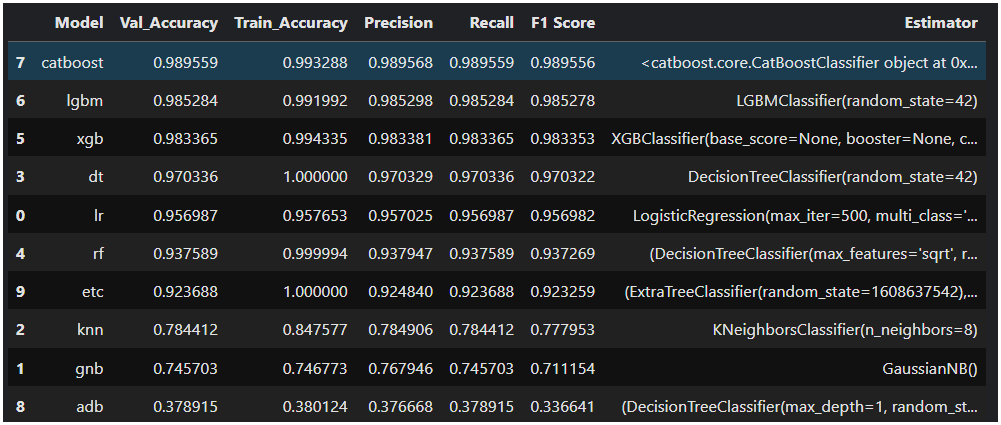'](http://)

### This Result Come Without Grid Search or CV ,So I will Select only Best Models To Apply GridSearch

In [52]:
cv = StratifiedKFold(n_splits=5,
                     shuffle=True,
                     random_state=42)

In [53]:
n_classes = 5  

models_and_grids = {


    
    "CatBoost": {
        "model": CatBoostClassifier(
            loss_function="MultiClass",  
            task_type="GPU",              
            devices='0',                  
            random_state=42,
            verbose=0
        ),
        "params": None  
    },

    "XGBoost": {
        "model": XGBClassifier(
        objective="multi:softprob",
        tree_method='hist',  
        device='gpu',
        random_state=42,
        verbosity=0
        ),
        "params": {
            "n_estimators": [200, 400, 600],
            "max_depth": [3, 5, 7],
            "learning_rate": [0.01, 0.05],
        }
    },

    "LightGBM": {
        "model": LGBMClassifier(
            objective="multiclass",
            device='gpu',               
            num_class=n_classes,
            random_state=42,
            verbose=-1
        ),
        "params": {
            "learning_rate": [0.01, 0.05],
            "n_estimators": [200, 400, 600]
        }
    },

    "RandomForest": {
        "model": RandomForestClassifier(
            random_state=42
        ),
        "params": {
            "n_estimators": [100, 200 , 400],
            "max_depth": [None, 10 , 15]
        }
    },

    "DecisionTree": {
        "model": DecisionTreeClassifier(
            random_state=42
        ),
        "params": {
            "max_depth": [None, 10, 20],
            "min_samples_split": [2, 5, 10]
        }
    },

    "LogisticRegression": {
        "model": LogisticRegression(
            random_state=42,
            max_iter=1000,
            multi_class="multinomial", 
            solver="lbfgs"
        ),
        "params": {
            "C": [0.01, 0.1, 1, 10],
            "penalty": ["l2"]
        }
    },

    "VotingClassifier": {
        "model": VotingClassifier(
            estimators=[
                ("cat", CatBoostClassifier(
                    loss_function="MultiClass",
                    task_type="GPU",        
                    devices='0',
                    random_state=42,
                    verbose=0
                )),
                ("lgbm", LGBMClassifier(
                    objective="multiclass",
                    device='gpu',           
                    num_class=n_classes,
                    random_state=42
                )),
                ("xgb", XGBClassifier(
                    objective="multi:softprob",
                    tree_method='hist',  
                    device='gpu',
                    random_state=42,
                    verbosity=0
                ))
            ],
            voting="soft"
        ),
        "params": None
    }
}


In [54]:
def Training(models_and_grids, X_train, y_train, X_val, y_val, cv):

    results = []

    scoring = {
        "accuracy": "accuracy",
        "precision": "precision_weighted",
        "recall": "recall_weighted",
        "f1": "f1_weighted"
    }

    for name, value in models_and_grids.items():

        print(f"\nTraining Model: {name}")
        print("=" * 60)

        # Train 
        if value["params"] is None:
            model = value["model"]
            model.fit(X_train, y_train)
            best_params = "No GridSearch"

        else:
            grid = GridSearchCV(
                estimator=value["model"],
                param_grid=value["params"],
                scoring=scoring,
                refit="f1",
                cv=cv,
                n_jobs=1,
                verbose=0,
                error_score='raise'

            )
            grid.fit(X_train, y_train)
            model = grid.best_estimator_
            best_params = grid.best_params_

        #  Predict 
        y_pred = model.predict(X_val)
        y_train_pred = model.predict(X_train)

        # Metrics 
        acc = accuracy_score(y_val, y_pred)
        train_acc = accuracy_score(y_train, y_train_pred)
        prec = precision_score(y_val, y_pred, average="weighted")
        rec = recall_score(y_val, y_pred, average="weighted")
        f1 = f1_score(y_val, y_pred, average="weighted")

        results.append({
            "Model": name,
            "Val_Accuracy": acc,
            "Train_Accuracy": train_acc,
            "Precision": prec,
            "Recall": rec,
            "F1 Score": f1,
            "Best Params": best_params,
            "Estimator": model
        })

        print(f"{name} Val Accuracy: {acc:.4f}")
        print(f"Train Accuracy: {train_acc:.4f}")

        print("\nClassification Report:")
        print(classification_report(y_val, y_pred))

        cm = confusion_matrix(y_val, y_pred)
        ConfusionMatrixDisplay(cm).plot(cmap=plt.cm.Blues)
        plt.title(f"Confusion Matrix - {name}")
        plt.show()

    return results



Training Model: CatBoost
CatBoost Val Accuracy: 0.9518
Train Accuracy: 0.9688

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.91      0.92      2187
           1       0.94      0.95      0.95      4047
           2       0.95      0.97      0.96      6761
           3       0.94      0.93      0.93      8488
           4       0.97      0.97      0.97     12902

    accuracy                           0.95     34385
   macro avg       0.95      0.94      0.94     34385
weighted avg       0.95      0.95      0.95     34385



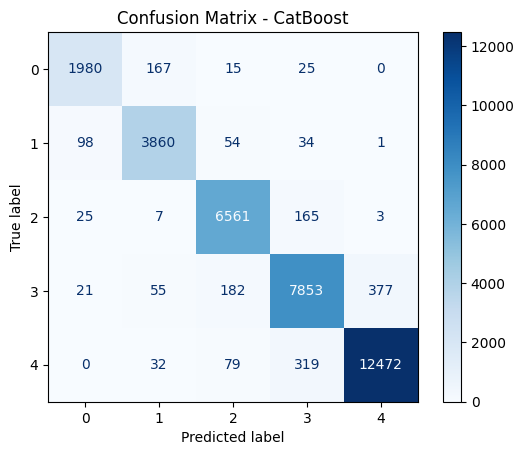


Training Model: XGBoost
XGBoost Val Accuracy: 0.9459
Train Accuracy: 0.9713

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.84      0.88      2187
           1       0.90      0.95      0.93      4047
           2       0.94      0.98      0.96      6761
           3       0.95      0.91      0.93      8488
           4       0.96      0.97      0.97     12902

    accuracy                           0.95     34385
   macro avg       0.94      0.93      0.93     34385
weighted avg       0.95      0.95      0.95     34385



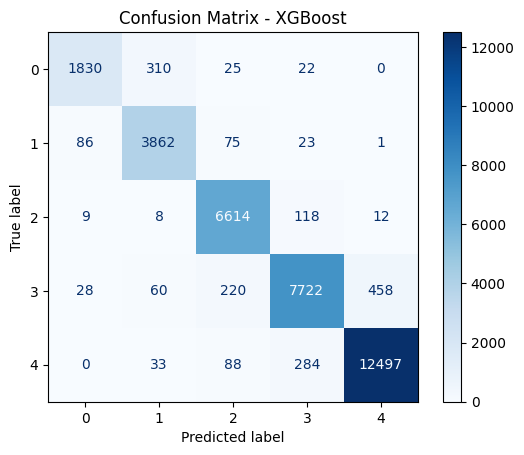


Training Model: LightGBM


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


LightGBM Val Accuracy: 0.9540
Train Accuracy: 0.9711

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.87      0.91      2187
           1       0.92      0.96      0.94      4047
           2       0.95      0.98      0.96      6761
           3       0.95      0.92      0.94      8488
           4       0.97      0.97      0.97     12902

    accuracy                           0.95     34385
   macro avg       0.95      0.94      0.94     34385
weighted avg       0.95      0.95      0.95     34385



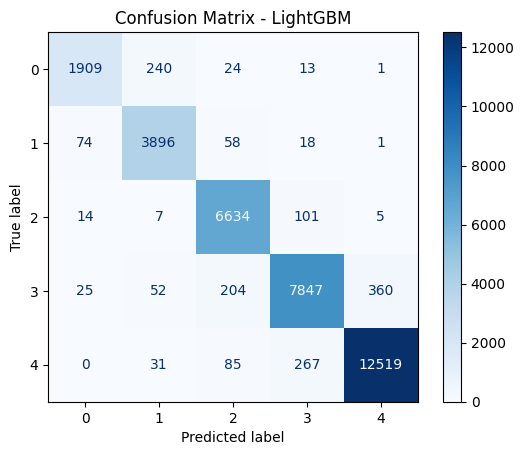


Training Model: RandomForest
RandomForest Val Accuracy: 0.8658
Train Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.62      0.73      2187
           1       0.82      0.86      0.84      4047
           2       0.83      0.90      0.86      6761
           3       0.85      0.77      0.81      8488
           4       0.91      0.96      0.93     12902

    accuracy                           0.87     34385
   macro avg       0.86      0.82      0.83     34385
weighted avg       0.87      0.87      0.86     34385



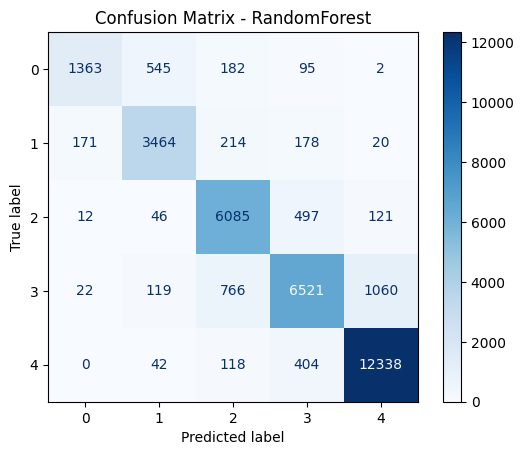


Training Model: DecisionTree
DecisionTree Val Accuracy: 0.8226
Train Accuracy: 0.9307

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.60      0.61      2187
           1       0.74      0.75      0.74      4047
           2       0.80      0.83      0.82      6761
           3       0.78      0.78      0.78      8488
           4       0.93      0.91      0.92     12902

    accuracy                           0.82     34385
   macro avg       0.77      0.77      0.77     34385
weighted avg       0.82      0.82      0.82     34385



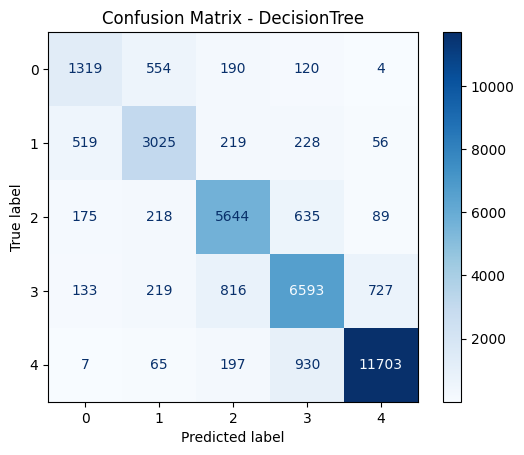


Training Model: LogisticRegression
LogisticRegression Val Accuracy: 0.7235
Train Accuracy: 0.7251

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.60      0.66      2187
           1       0.73      0.71      0.72      4047
           2       0.73      0.76      0.74      6761
           3       0.56      0.54      0.55      8488
           4       0.82      0.85      0.84     12902

    accuracy                           0.72     34385
   macro avg       0.71      0.69      0.70     34385
weighted avg       0.72      0.72      0.72     34385



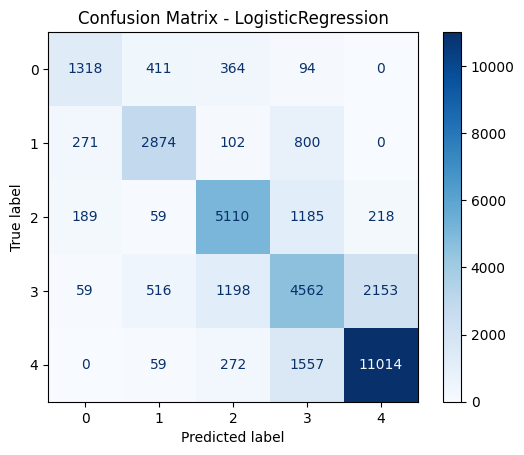


Training Model: VotingClassifier
VotingClassifier Val Accuracy: 0.9439
Train Accuracy: 0.9601

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.85      0.89      2187
           1       0.91      0.95      0.93      4047
           2       0.94      0.98      0.96      6761
           3       0.94      0.90      0.92      8488
           4       0.96      0.97      0.96     12902

    accuracy                           0.94     34385
   macro avg       0.94      0.93      0.93     34385
weighted avg       0.94      0.94      0.94     34385



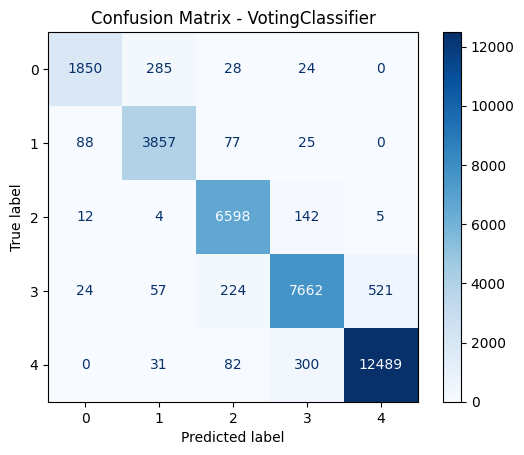

In [55]:
all_results = Training(models_and_grids, X_train, y_train, X_val, y_val, cv)  
results = all_results   # I take copy to avoid Train again
results_df = pd.DataFrame(results)

## Neural Network

In [56]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical

num_classes = 5

# One-hot encoding
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical

num_classes = 5

# One-hot encoding
y_train_cat = to_categorical(y_train, num_classes)
y_val_cat   = to_categorical(y_val, num_classes)
y_test_cat  = to_categorical(y_test, num_classes)

# Model
ANN_model = models.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.3),
    
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    
    layers.Dense(32, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

# Optimizer
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

# Compile
ANN_model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.F1Score(        
            average='weighted',
            name="f1_score"
        )
    ]
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = ANN_model.fit(
    X_train, y_train_cat,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val_cat),
    callbacks=[early_stop]
)


2026-03-27 09:26:47.780821: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774603608.004073      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774603608.068030      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774603608.587855      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774603608.587899      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774603608.587902      55 computation_placer.cc:177] computation placer alr

Epoch 1/100


I0000 00:00:1774603625.500642     358 service.cc:152] XLA service 0x7910f40089c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774603625.500678     358 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774603625.500682     358 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774603625.896667     358 cuda_dnn.cc:529] Loaded cuDNN version 91002


  63/5015 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 0.3807 - f1_score: 0.3126 - loss: 1.4500 - precision: 0.6186 - recall: 0.0916 

I0000 00:00:1774603628.037239     358 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


5015/5015 ━━━━━━━━━━━━━━━━━━━━ 23s 4ms/step - accuracy: 0.7597 - f1_score: 0.7534 - loss: 0.5937 - precision: 0.8293 - recall: 0.6862 - val_accuracy: 0.9438 - val_f1_score: 0.9432 - val_loss: 0.1601 - val_precision: 0.9454 - val_recall: 0.9425
Epoch 2/100
5015/5015 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.9270 - f1_score: 0.9269 - loss: 0.2039 - precision: 0.9297 - recall: 0.9238 - val_accuracy: 0.9579 - val_f1_score: 0.9578 - val_loss: 0.1263 - val_precision: 0.9591 - val_recall: 0.9564
Epoch 3/100
5015/5015 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.9401 - f1_score: 0.9400 - loss: 0.1696 - precision: 0.9420 - recall: 0.9377 - val_accuracy: 0.9518 - val_f1_score: 0.9513 - val_loss: 0.1355 - val_precision: 0.9528 - val_recall: 0.9505
Epoch 4/100
5015/5015 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.9444 - f1_score: 0.9445 - loss: 0.1570 - precision: 0.9462 - recall: 0.9426 - val_accuracy: 0.9667 - val_f1_score: 0.9668 - val_loss: 0.1050 - val_precision: 0.9672 - val_rec

In [57]:
ANN_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         5,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,017 (187.57 KB)

 Trainable params: 16,005 (62.52 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 32,012 (125.05 KB)

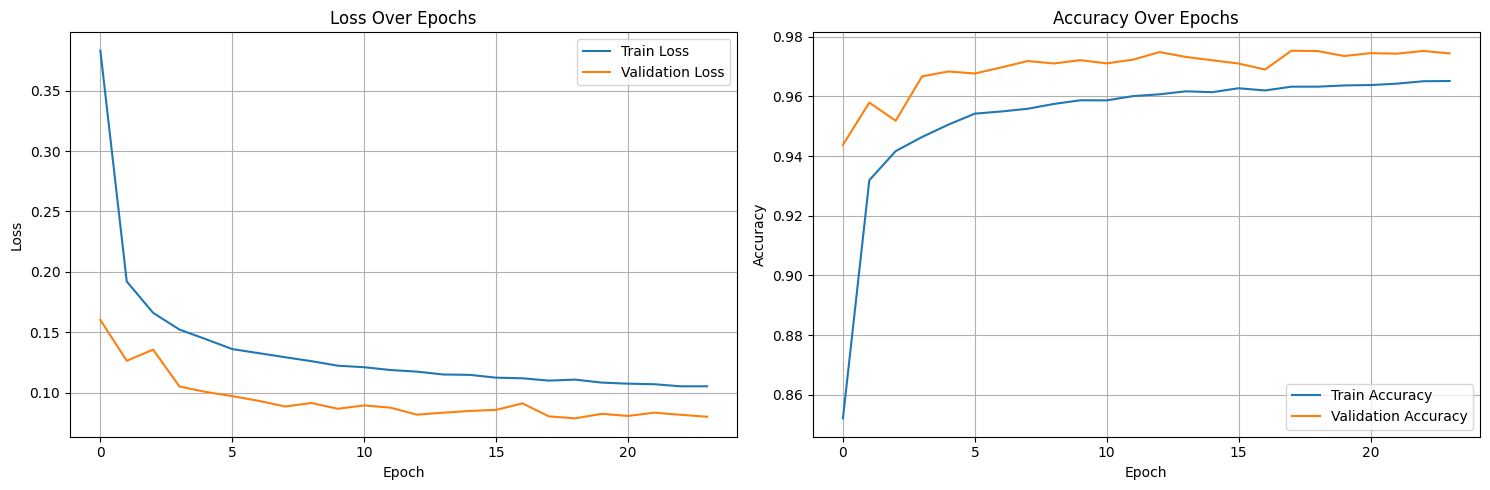

In [58]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Loss Over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_title('Accuracy Over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


In [59]:
results.append({
    "Model": "ANN",
    "Val_Accuracy": history.history['val_accuracy'][-1],
    "Train_Accuracy": history.history['accuracy'][-1],
    "Precision": history.history['precision'][-1],
    "Recall": history.history['recall'][-1],
    "F1 Score": history.history['f1_score'][-1],    
    'Estimator': ANN_model
})

In [60]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Val_Accuracy", ascending=False)

In [61]:
results_df

,Model,Val_Accuracy,Train_Accuracy,Precision,Recall,F1 Score,Best Params,Estimator
7,ANN,0.974437,0.965182,0.965775,0.964583,0.965230,NaN,"<Sequential name=sequential, built=True>"
2,LightGBM,0.954050,0.971071,0.954210,0.954050,0.953881,"{'learning_rate': 0.05, 'n_estimators': 600}","LGBMClassifier(device='gpu', learning_rate=0.0..."
0,CatBoost,0.951752,0.968796,0.951730,0.951752,0.951694,No GridSearch,<catboost.core.CatBoostClassifier object at 0x...
1,XGBoost,0.945907,0.971283,0.946113,0.945907,0.945595,"{'learning_rate': 0.05, 'max_depth': 7, 'n_est...","XGBClassifier(base_score=None, booster=None, c..."
6,VotingClassifier,0.943900,0.960090,0.943964,0.943900,0.943567,No GridSearch,"VotingClassifier(estimators=[('cat',\n ..."
3,RandomForest,0.865814,1.000000,0.865522,0.865814,0.863343,"{'max_depth': None, 'n_estimators': 400}","(DecisionTreeClassifier(max_features='sqrt', r..."
4,DecisionTree,0.822568,0.930725,0.823689,0.822568,0.822991,"{'max_depth': 20, 'min_samples_split': 10}","DecisionTreeClassifier(max_depth=20, min_sampl..."
5,LogisticRegression,0.723513,0.725073,0.720670,0.723513,0.721543,"{'C': 0.01, 'penalty': 'l2'}","LogisticRegression(C=0.01, max_iter=1000, mult..."


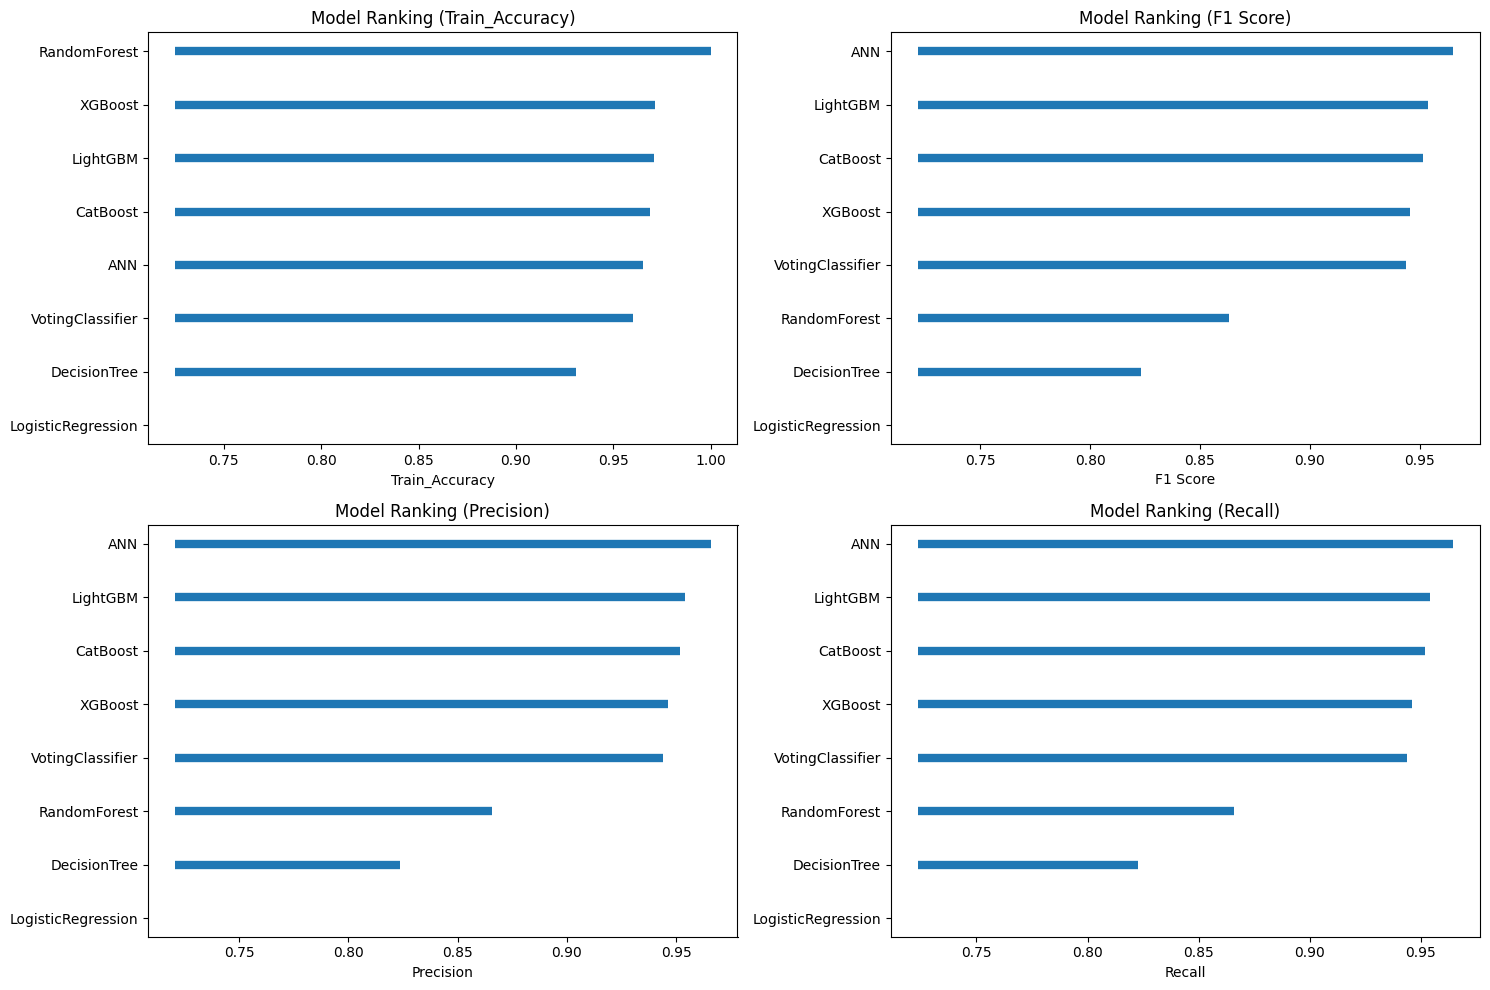

In [62]:
import matplotlib as mpl
plt.figure(figsize=(15, 10))

def Draw_Compare(i , x  , y , results_df , name):
    
    plt.subplot(2,2,i)
    sorted_df = results_df.sort_values(y)

    plt.hlines(
        y=sorted_df["Model"],
        xmin=sorted_df[y].min(),
        xmax=sorted_df[y],
        linewidth=6
    )
    
    plt.xlabel(f"{name}")
    plt.title(f"Model Ranking ({name})")


Draw_Compare(1, 'Model'  , "Train_Accuracy" , results_df , 'Train_Accuracy')
Draw_Compare(2, 'Model' , "F1 Score", results_df , 'F1 Score')
Draw_Compare(3, 'Model' , "Precision", results_df , 'Precision')
Draw_Compare(4, 'Model' , "Recall", results_df , 'Recall')

plt.tight_layout()
plt.show()





<hr style="border: 2px solid #1b3fc3ff; width: 80%;">
<h1 style="text-align:center; font-family: 'Arial', sans-serif; color : white;">
5 - Best Model
</h1>
<hr style="border: 2px solid #1b3fc3ff; width: 80%;">

In [63]:
sorted_df = results_df.sort_values(by=['Recall' , "F1 Score",'Precision'], ascending=False)
sorted_df

,Model,Val_Accuracy,Train_Accuracy,Precision,Recall,F1 Score,Best Params,Estimator
7,ANN,0.974437,0.965182,0.965775,0.964583,0.965230,NaN,"<Sequential name=sequential, built=True>"
2,LightGBM,0.954050,0.971071,0.954210,0.954050,0.953881,"{'learning_rate': 0.05, 'n_estimators': 600}","LGBMClassifier(device='gpu', learning_rate=0.0..."
0,CatBoost,0.951752,0.968796,0.951730,0.951752,0.951694,No GridSearch,<catboost.core.CatBoostClassifier object at 0x...
1,XGBoost,0.945907,0.971283,0.946113,0.945907,0.945595,"{'learning_rate': 0.05, 'max_depth': 7, 'n_est...","XGBClassifier(base_score=None, booster=None, c..."
6,VotingClassifier,0.943900,0.960090,0.943964,0.943900,0.943567,No GridSearch,"VotingClassifier(estimators=[('cat',\n ..."
3,RandomForest,0.865814,1.000000,0.865522,0.865814,0.863343,"{'max_depth': None, 'n_estimators': 400}","(DecisionTreeClassifier(max_features='sqrt', r..."
4,DecisionTree,0.822568,0.930725,0.823689,0.822568,0.822991,"{'max_depth': 20, 'min_samples_split': 10}","DecisionTreeClassifier(max_depth=20, min_sampl..."
5,LogisticRegression,0.723513,0.725073,0.720670,0.723513,0.721543,"{'C': 0.01, 'penalty': 'l2'}","LogisticRegression(C=0.01, max_iter=1000, mult..."


In [64]:
Final_model = sorted_df['Estimator'].iloc[0]
Final_model

<Sequential name=sequential, built=True>

In [68]:
print(type(Final_model))

<class 'keras.src.models.sequential.Sequential'>


In [69]:
# Use This Code If your model is Not Neural Network To see Feature Importance 
#----------------------------------------------------------------------------
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# importances = Final_model.feature_importances_
# features = x.columns

# fi = pd.DataFrame({
#     "feature": features,
#     "importance": importances
# }).sort_values(by="importance", ascending=False)

# plt.figure(figsize=(10,8))
# sns.barplot(
#     data=fi,
#     x="importance",
#     y="feature"
# )
# plt.title("Feature Importance")
# plt.tight_layout()
# plt.show()


1075/1075 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Test Accuracy : 0.9749
Test F1_Score : 0.9750
Test Precision: 0.9753
Test Recall   : 0.9749

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.96      2188
           1       0.98      0.96      0.97      4046
           2       0.95      0.99      0.97      6762
           3       0.97      0.97      0.97      8488
           4       1.00      0.98      0.99     12901

    accuracy                           0.97     34385
   macro avg       0.97      0.97      0.97     34385
weighted avg       0.98      0.97      0.97     34385



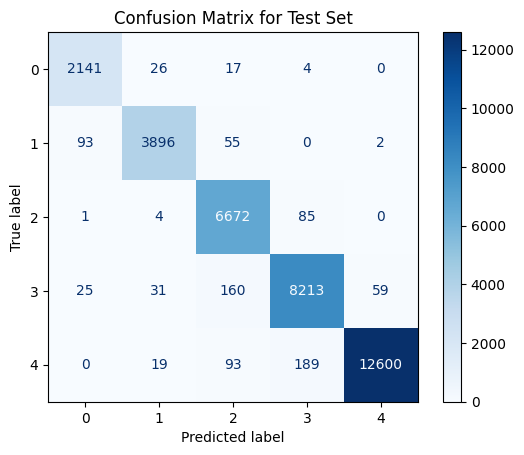

In [70]:
from tensorflow.keras.models import Sequential

def evaluate_model(model, X_test, y_test, num_classes=None):
    
    if isinstance(model, Sequential):
        y_pred_prob = model.predict(X_test)
        y_pred = np.argmax(y_pred_prob, axis=1)
        
        if num_classes is None:
            raise ValueError("num_classes must be provided for ANN evaluation")
        y_true = np.argmax(y_test, axis=1)
    else:
        y_pred = model.predict(X_test)
        y_true = y_test 

        plt.figure(figsize = (15 ,10))
        feature_importance_df = pd.DataFrame({
            "feature": x.columns,
            "importance": Final_model.get_feature_importance()
        }).sort_values(by="importance", ascending=False)
        
        feature_importance_df.plot(kind = 'bar' , x = 'feature' , y='importance')
        
        plt.tight_layout()
        plt.show()

    
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average="weighted")
    prec = precision_score(y_true, y_pred, average="weighted")
    rec  = recall_score(y_true, y_pred, average="weighted")
    
    print(f"Test Accuracy : {acc:.4f}")
    print(f"Test F1_Score : {f1:.4f}")
    print(f"Test Precision: {prec:.4f}")
    print(f"Test Recall   : {rec:.4f}\n")
    
    print("Classification Report:")   
    print(classification_report(y_true, y_pred, digits=2))
    
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=range(num_classes) if isinstance(model, Sequential) else np.unique(y_true))
    disp.plot(cmap="Blues", values_format="d")
    plt.title('Confusion Matrix for Test Set')
    plt.show()


evaluate_model(ANN_model, X_test, y_test_cat, num_classes=num_classes)






<hr style="border: 2px solid #1b3fc3ff; width: 80%;">
<h1 style="text-align:center; font-family: 'Arial', sans-serif; color : white;">
6 - Save Model for Deployment
</h1>
<hr style="border: 2px solid #1b3fc3ff; width: 80%;">

In [71]:
import joblib
joblib.dump(Final_model, "Best_Rating_model.pkl")


['Best_Rating_model.pkl']